### 工作進度  
* 新的筆記架構仍待定。

#### 引入模組與定義公用函式  

In [1]:
import mysys
import markdown
import base64
from IPython.core.display import HTML

In [2]:
def stock_analysis( analysis, stock_id, buttom_pattern = False) :
    results,images = analysis.analysis(stock_id)
    if buttom_pattern is True and '底部型態' in images :
        print('底型反轉交易策略：')
        display(images['底部型態'])
    print('解盤內容：')
    if '整體評價' in images :
        display(images['整體評價'])
    result_md   = results.to_markdown(tablefmt="grid")
    result_html = markdown.markdown(result_md, extensions=['markdown_grid_tables:GridTableExtension'])
    display(HTML(result_html))

In [3]:
def date_to_index(df_in,date_in) :
    number_array = df_in.index == date_in
    idx = 0
    for number_index in number_array :
        if number_index == True :
            break
        idx = idx + 1
    return idx

#### 建立「解盤」物件    

In [4]:
analysis = mysys.StockAnalysis()

### 指數解盤  

* 加權指數

解盤內容：


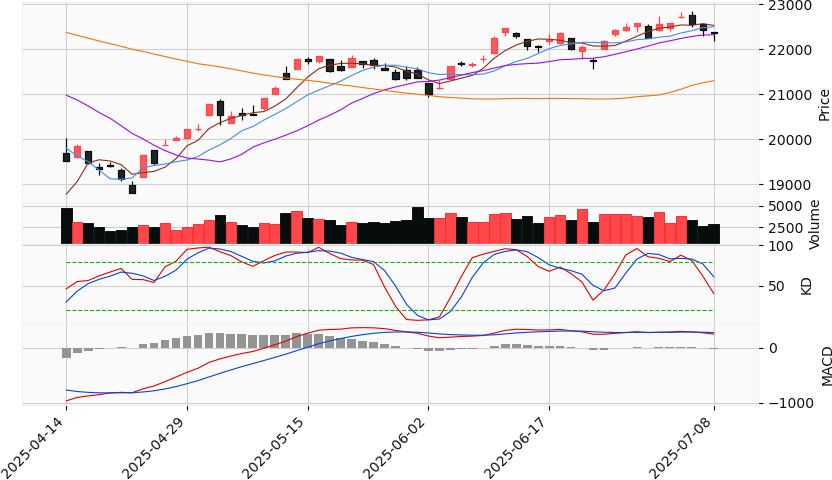

技術分析工具,解盤內容
Ｋ線／Ｋ棒,"紡錘線 : 2025-07-03 十字線 : 2025-07-03 , 2025-07-08 吞噬 : 2025-07-04"
Ｋ線圖,中期為高位階 長期為中位階
成交量,價量關係：未至大量門檻（成交量 ＝ 2827.06億元 ，十日均量 ＝ 3534.83億元）
型態,反轉型態之三重頂，型態範圍由2024-08-12開始到2025-03-03結束，估算目標價為21371.25。 底型反轉之底部型態，型態範圍由2025-04-02開始到2025-05-02結束，估算目標價為22257.56。
移動平均線,5日線下彎、10日線上揚，短期盤整；20日線上揚、60日線上揚，中期翻多；120日線下彎、240日線下彎，長期翻空
ＫＤ指標,於2025-07-04死亡交叉。
ＭＡＣＤ指標,MACD在零軸以上，中期多方
周Ｋ－周ＫＤ指標,於2025-06-23當周黃金交叉。並且2025-06-30該周在超買區。
整體評價,技術分析 價格趨勢 近期價格呈現盤整狀態。雖然之前有一段上漲趨勢，但目前價格在高位震盪，顯示出多空雙方的拉鋸。 價量關係 成交量在上漲過程中有所增加，但近期盤整時成交量減少，顯示出市場觀望情緒較重，買賣雙方力量均衡。 支撐與壓力 - 支撐位置：短期支撐在20日移動平均線（紫色線）附近。 - 壓力位置：上方壓力在近期高點附近，約在23000點。 KD 指標解讀 KD指標顯示K線（紅線）已經跌破D線（藍線），並且從超買區回落，顯示出短期內有回檔壓力。 MACD 指標解讀 MACD指標中，DIF線（紅線）與MACD線（藍線）接近零軸，且柱狀體縮短，顯示出動能減弱，市場可能進入盤整或回檔。 綜合評價 目前市場處於高位盤整階段，短期內可能會有回檔壓力。建議投資者謹慎操作，觀察支撐位的有效性，若跌破支撐位，需考慮停損。若價格能夠在支撐位企穩並放量上漲，則可考慮進一步加碼。


In [5]:
stock_analysis(analysis,'TAIEX')

* 櫃買指數

解盤內容：


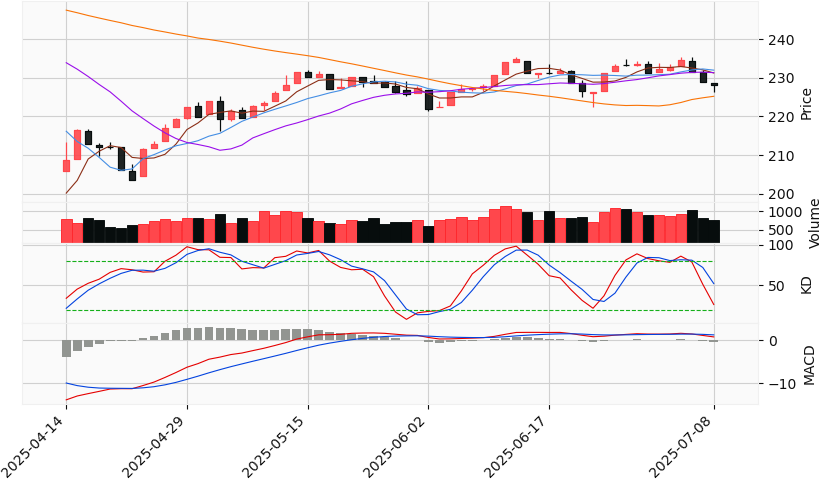

技術分析工具,解盤內容
Ｋ線／Ｋ棒,鎚子線／吊人線 : 2025-07-08
Ｋ線圖,中期為中位階 長期為低位階
成交量,價量關係：未至大量門檻（成交量 ＝ 776.99億元 ，十日均量 ＝ 933.19億元）
型態,盤整型態之三角形，型態範圍由2024-07-11開始到2025-03-28結束。 底型反轉之底部型態，型態範圍由2025-04-02開始到2025-05-02結束，估算目標價為247.79。
移動平均線,5日線下彎、10日線下彎，短期翻空；20日線下彎、60日線上揚，中期盤整；120日線下彎、240日線下彎，長期翻空
ＫＤ指標,於2025-07-04死亡交叉。
ＭＡＣＤ指標,MACD在零軸以上，中期多方
周Ｋ－周ＫＤ指標,於2025-06-02當周死亡交叉。
整體評價,價格趨勢分析 近期價格呈現盤整走勢，K線在230點附近波動。短期移動平均線（5日、10日）與中期移動平均線（20日、60日）糾結，顯示市場缺乏明確方向。 價量關係 成交量在近期有增加的趨勢，但價格未能有效突破，顯示多空雙方力量相對均衡，市場觀望情緒較重。 支撐與壓力判斷 - 支撐位置：230點附近，若跌破此位置，可能進一步下探至220點。 - 壓力位置：240點，若能有效突破，則有望進一步上行。 KD指標解讀 KD指標顯示K線與D線均向下，且K線已進入超賣區，顯示短期內可能有反彈需求，但需觀察是否能有效止跌。 MACD指標解讀 MACD指標中，DIF線與MACD線接近零軸，且灰色柱體縮短，顯示市場動能減弱，短期內可能維持盤整。 綜合評價 目前市場處於盤整階段，短期內可能有反彈需求，但需觀察支撐位的有效性。建議投資者謹慎操作，若價格跌破支撐位，需考慮停損；若價格突破壓力位，則可考慮適度加碼。


In [6]:
stock_analysis(analysis,'TPEx')